<a href="https://colab.research.google.com/github/adigenova/uohdm/blob/main/code/practico1_ggplot2_flight.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller de **ggplot2** con el dataset `flights`

Este notebook está diseñado para **aprender ggplot2 paso a paso**, desde lo más básico hasta técnicas más avanzadas, usando el dataset `flights` del paquete **nycflights13**.

## Objetivos
Al terminar este notebook deberías poder:

- Entender la lógica de la **gramática de gráficos**
- Crear gráficos básicos con `ggplot()`, `aes()` y distintos `geom_*()`
- Personalizar títulos, ejes, colores y temas
- Usar **facetas**, transformaciones y capas
- Construir visualizaciones más informativas para explorar datos reales

## Dataset
Usaremos `nycflights13::flights`, que contiene información de vuelos que salieron de Nueva York en 2013.

## Requisitos
Este notebook usa R. Si no tienes los paquetes instalados, ejecuta la siguiente celda.

In [2]:
# Instalar paquetes si es necesario
 install.packages(c("tidyverse", "nycflights13", "lubridate", "scales", "patchwork"))

library(tidyverse)
library(nycflights13)
library(lubridate)
library(scales)
library(patchwork)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




## 1. Cargar y conocer los datos

In [3]:
data("flights")
glimpse(flights)

Rows: 336,776
Columns: 19
$ year           <int> 2013, 2013, 2013, 2013, 2013, 2013, 2013, 2013, 2013, 2…
$ month          <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ day            <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ dep_time       <int> 517, 533, 542, 544, 554, 554, 555, 557, 557, 558, 558, …
$ sched_dep_time <int> 515, 529, 540, 545, 600, 558, 600, 600, 600, 600, 600, …
$ dep_delay      <dbl> 2, 4, 2, -1, -6, -4, -5, -3, -3, -2, -2, -2, -2, -2, -1…
$ arr_time       <int> 830, 850, 923, 1004, 812, 740, 913, 709, 838, 753, 849,…
$ sched_arr_time <int> 819, 830, 850, 1022, 837, 728, 854, 723, 846, 745, 851,…
$ arr_delay      <dbl> 11, 20, 33, -18, -25, 12, 19, -14, -8, 8, -2, -3, 7, -1…
$ carrier        <chr> "UA", "UA", "AA", "B6", "DL", "UA", "B6", "EV", "B6", "…
$ flight         <int> 1545, 1714, 1141, 725, 461, 1696, 507, 5708, 79, 301, 4…
$ tailnum        <chr> "N14228", "N24211", "N619AA", "N804JB", "N668DN", "N394…
$ origin      

### Variables importantes

Algunas columnas útiles en `flights` son:

- `year`, `month`, `day`: fecha del vuelo
- `dep_time`, `arr_time`: hora de salida y llegada
- `dep_delay`, `arr_delay`: retraso en salida y llegada (en minutos)
- `carrier`: aerolínea
- `flight`: número de vuelo
- `origin`, `dest`: aeropuerto de origen y destino
- `air_time`: tiempo en el aire
- `distance`: distancia del vuelo

## 2. Idea central de ggplot2

La estructura general es:

```r
ggplot(datos, aes(...)) +
  geom_...
```

Donde:

- `datos` = tabla
- `aes()` = mapeo estético (qué variable va a x, y, color, etc.)
- `geom_*()` = el tipo de gráfico

## 3. Primer gráfico: histograma

Veamos cómo se distribuye el retraso de salida (`dep_delay`).

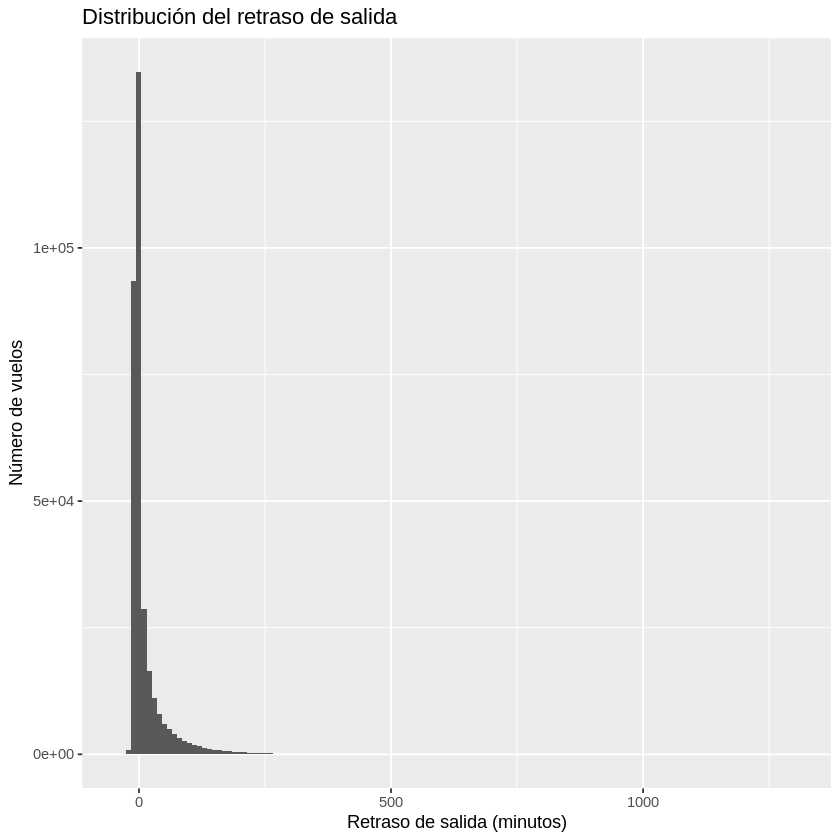

In [6]:
flights %>%
  filter(!is.na(dep_delay)) %>%
  ggplot(aes(x = dep_delay)) +
  geom_histogram(binwidth = 10) +
  labs(
    title = "Distribución del retraso de salida",
    x = "Retraso de salida (minutos)",
    y = "Número de vuelos"
  )

### Observación
- Valores **positivos** indican vuelos que salieron tarde.
- Valores **negativos** indican vuelos que salieron antes de lo programado.

## 4. Scatterplot básico

Ahora veamos la relación entre distancia y retraso de llegada.

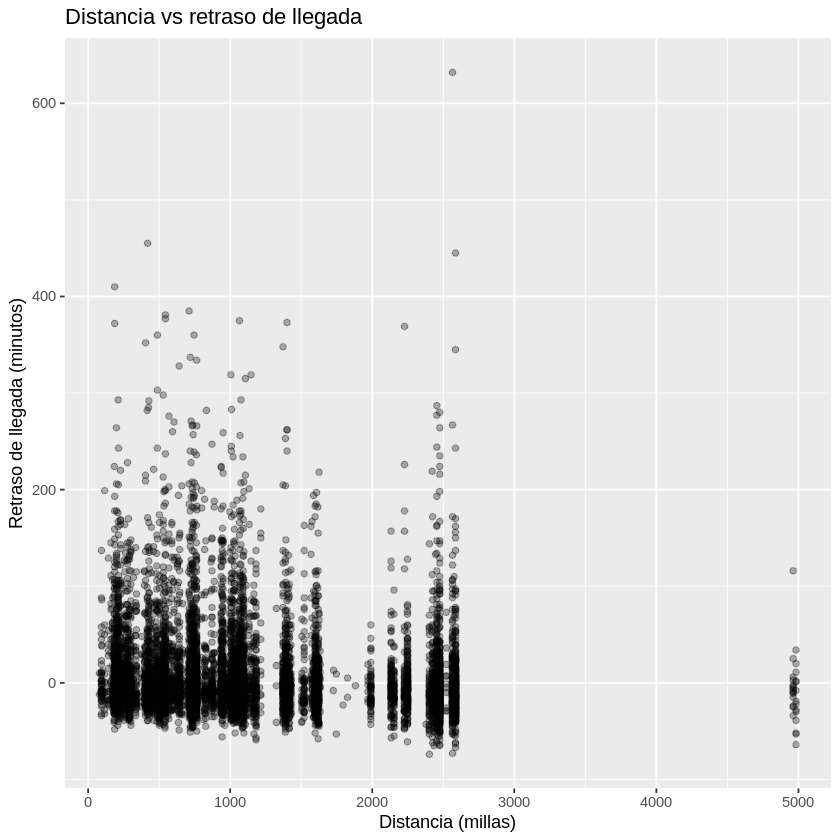

In [7]:
flights %>%
  filter(!is.na(arr_delay), !is.na(distance)) %>%
  sample_n(10000) %>%
  ggplot(aes(x = distance, y = arr_delay)) +
  geom_point(alpha = 0.3) +
  labs(
    title = "Distancia vs retraso de llegada",
    x = "Distancia (millas)",
    y = "Retraso de llegada (minutos)"
  )

### Nota
Usamos `sample_n(10000)` para no dibujar demasiados puntos, porque el dataset es grande.

## 5. Mapeos estéticos

Además de `x` e `y`, podemos mapear otras variables a:

- `color`
- `size`
- `shape`
- `alpha`

Por ejemplo, colorear por aeropuerto de origen.

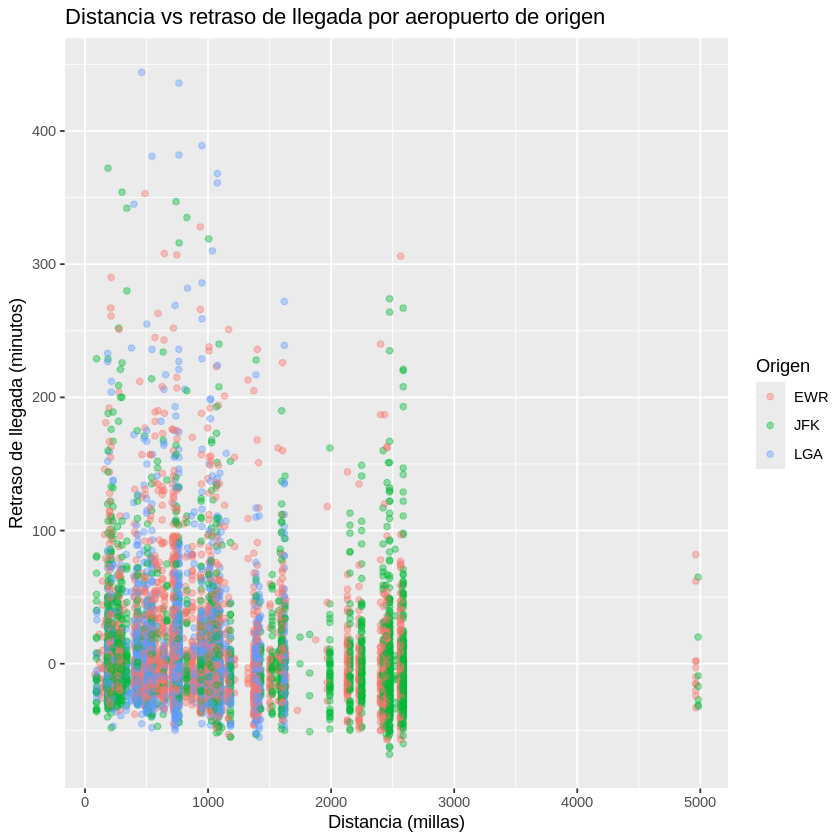

In [8]:
flights %>%
  filter(!is.na(arr_delay), !is.na(distance)) %>%
  sample_n(8000) %>%
  ggplot(aes(x = distance, y = arr_delay, color = origin)) +
  geom_point(alpha = 0.4) +
  labs(
    title = "Distancia vs retraso de llegada por aeropuerto de origen",
    x = "Distancia (millas)",
    y = "Retraso de llegada (minutos)",
    color = "Origen"
  )

## 6. Diferencia entre mapear y fijar una estética

### Caso 1: color mapeado a una variable

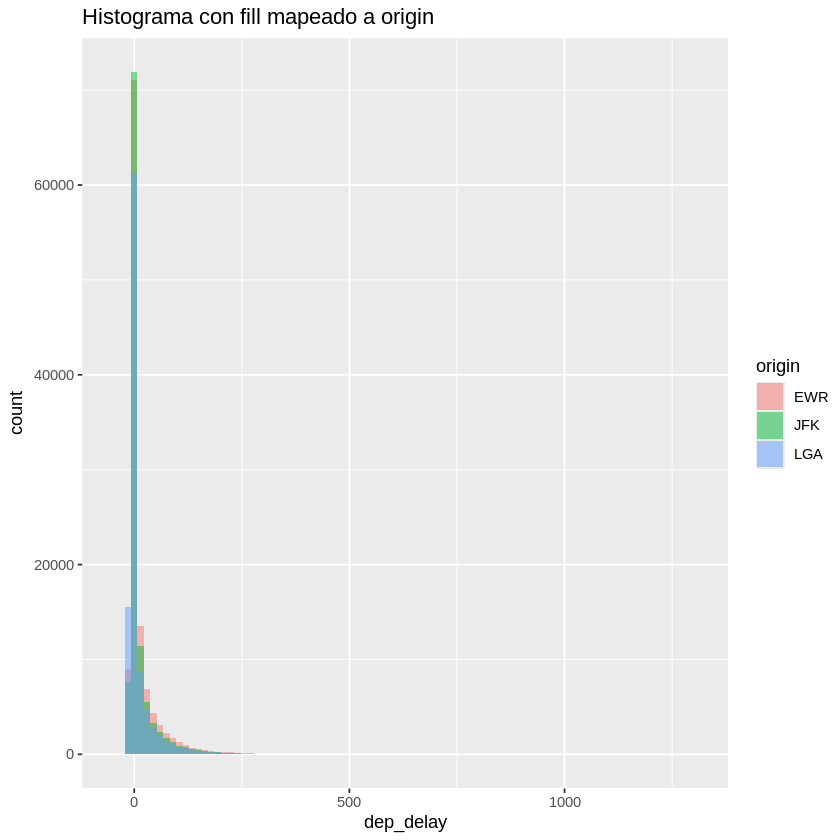

In [9]:
flights %>%
  filter(!is.na(dep_delay)) %>%
  ggplot(aes(x = dep_delay, fill = origin)) +
  geom_histogram(binwidth = 15, position = "identity", alpha = 0.5) +
  labs(title = "Histograma con fill mapeado a origin")

### Caso 2: color fijo

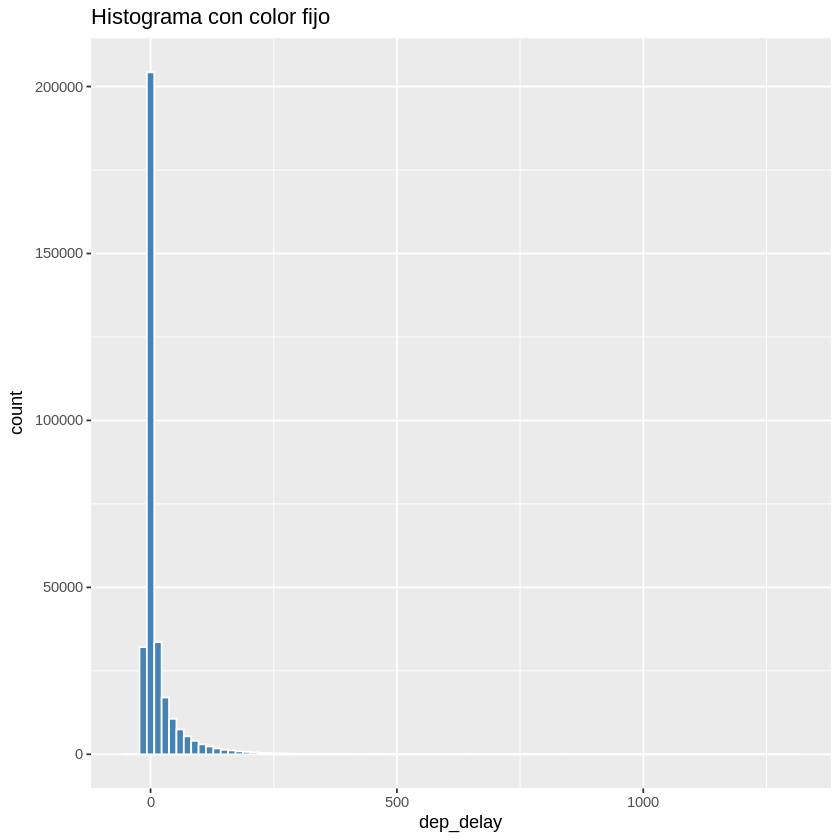

In [10]:
flights %>%
  filter(!is.na(dep_delay)) %>%
  ggplot(aes(x = dep_delay)) +
  geom_histogram(binwidth = 15, fill = "steelblue", color = "white") +
  labs(title = "Histograma con color fijo")

## 7. Gráficos de barras

Para variables categóricas, `geom_bar()` cuenta automáticamente observaciones.

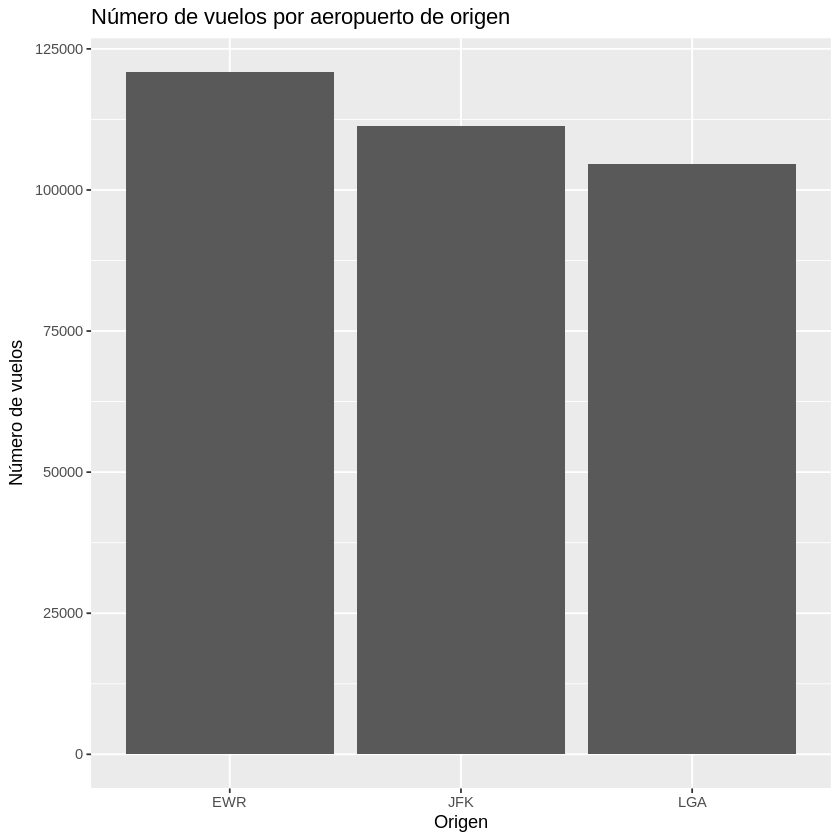

In [11]:
flights %>%
  ggplot(aes(x = origin)) +
  geom_bar() +
  labs(
    title = "Número de vuelos por aeropuerto de origen",
    x = "Origen",
    y = "Número de vuelos"
  )

### Reordenar barras

Podemos resumir y ordenar aerolíneas por retraso promedio.

In [12]:
carrier_delay <- flights %>%
  filter(!is.na(arr_delay)) %>%
  group_by(carrier) %>%
  summarise(
    atraso_prom = mean(arr_delay),
    n = n()
  ) %>%
  filter(n >= 1000) %>%
  arrange(atraso_prom)

carrier_delay

carrier,atraso_prom,n
<chr>,<dbl>,<int>
AA,0.3642909,31947
DL,1.6443409,47658
VX,1.7644644,5116
US,2.1295951,19831
UA,3.5580111,57782
9E,7.3796692,17294
B6,9.4579733,54049
WN,9.6491199,12044
MQ,10.7747334,25037


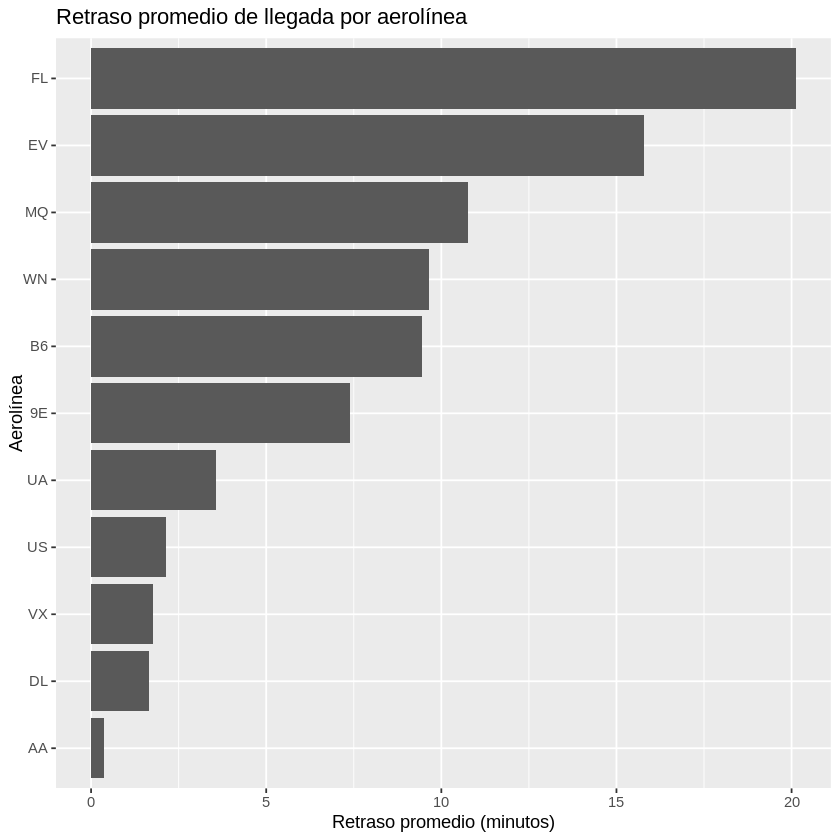

In [13]:
carrier_delay %>%
  ggplot(aes(x = reorder(carrier, atraso_prom), y = atraso_prom)) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Retraso promedio de llegada por aerolínea",
    x = "Aerolínea",
    y = "Retraso promedio (minutos)"
  )

## 8. Boxplots

Los boxplots ayudan a comparar distribuciones entre grupos.

Warning message in geom_boxplot(outlier_alpha = 0.2):
“Ignoring unknown parameters: `outlier_alpha`”


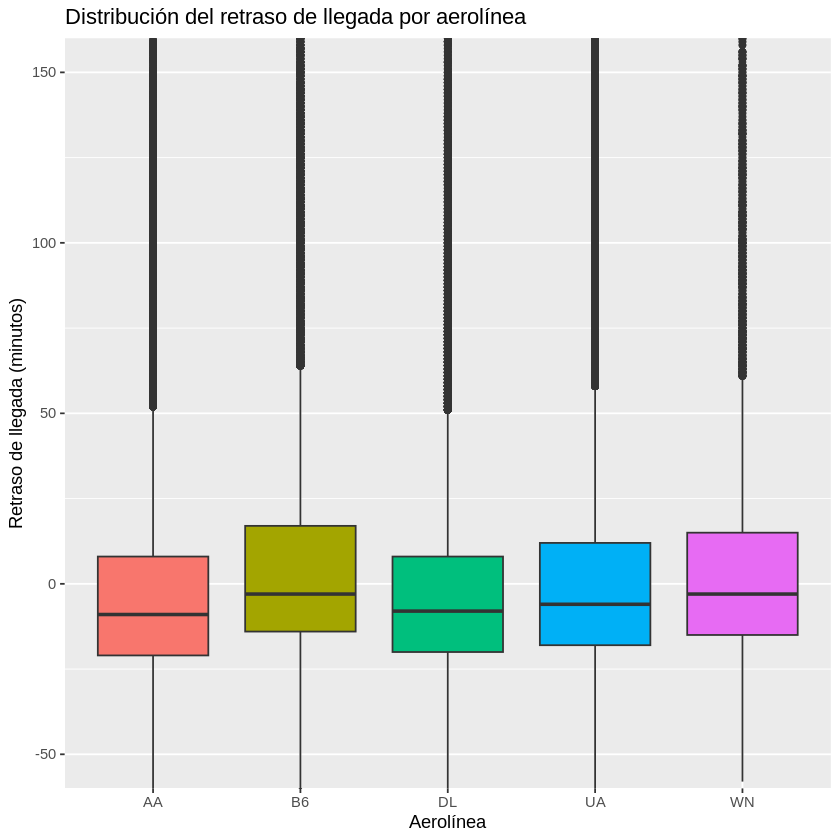

In [14]:
flights %>%
  filter(!is.na(arr_delay), carrier %in% c("AA", "DL", "UA", "B6", "WN")) %>%
  ggplot(aes(x = carrier, y = arr_delay, fill = carrier)) +
  geom_boxplot(outlier_alpha = 0.2) +
  coord_cartesian(ylim = c(-50, 150)) +
  labs(
    title = "Distribución del retraso de llegada por aerolínea",
    x = "Aerolínea",
    y = "Retraso de llegada (minutos)"
  ) +
  theme(legend.position = "none")

## 9. Facetas

Las facetas permiten repetir el mismo gráfico para distintos subconjuntos.

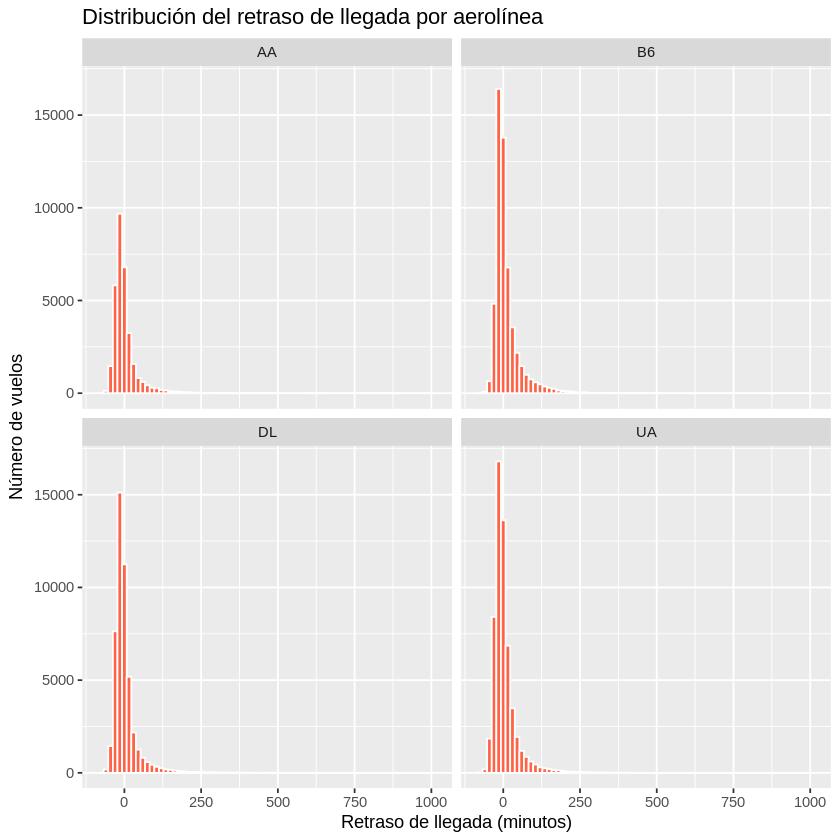

In [15]:
flights %>%
  filter(!is.na(arr_delay), carrier %in% c("AA", "DL", "UA", "B6")) %>%
  ggplot(aes(x = arr_delay)) +
  geom_histogram(binwidth = 15, fill = "tomato", color = "white") +
  facet_wrap(~ carrier, ncol = 2) +
  labs(
    title = "Distribución del retraso de llegada por aerolínea",
    x = "Retraso de llegada (minutos)",
    y = "Número de vuelos"
  )

### Facetas por dos variables

Primero construiremos una variable de estación.

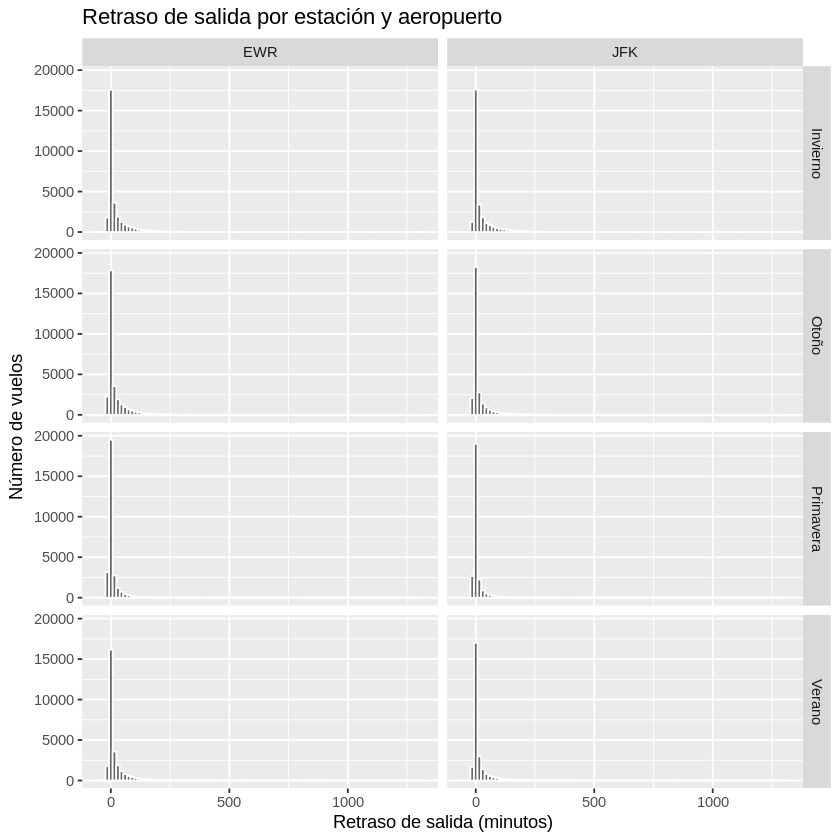

In [16]:
flights2 <- flights %>%
  mutate(
    estacion = case_when(
      month %in% c(12, 1, 2) ~ "Verano",
      month %in% c(3, 4, 5) ~ "Otoño",
      month %in% c(6, 7, 8) ~ "Invierno",
      TRUE ~ "Primavera"
    )
  )

flights2 %>%
  filter(!is.na(dep_delay), origin %in% c("EWR", "JFK")) %>%
  ggplot(aes(x = dep_delay)) +
  geom_histogram(binwidth = 15, fill = "gray40", color = "white") +
  facet_grid(estacion ~ origin) +
  labs(
    title = "Retraso de salida por estación y aeropuerto",
    x = "Retraso de salida (minutos)",
    y = "Número de vuelos"
  )

## 10. Gráficos de líneas

Para usar líneas, normalmente resumimos datos a lo largo del tiempo.

In [17]:
delay_month <- flights %>%
  filter(!is.na(arr_delay)) %>%
  group_by(month) %>%
  summarise(arr_delay_prom = mean(arr_delay))

delay_month

month,arr_delay_prom
<int>,<dbl>
1,6.1299720
2,5.6130194
3,5.8075765
4,11.1760630
5,3.5215088
6,16.4813296
7,16.7113067
8,6.0406524
9,-4.0183636


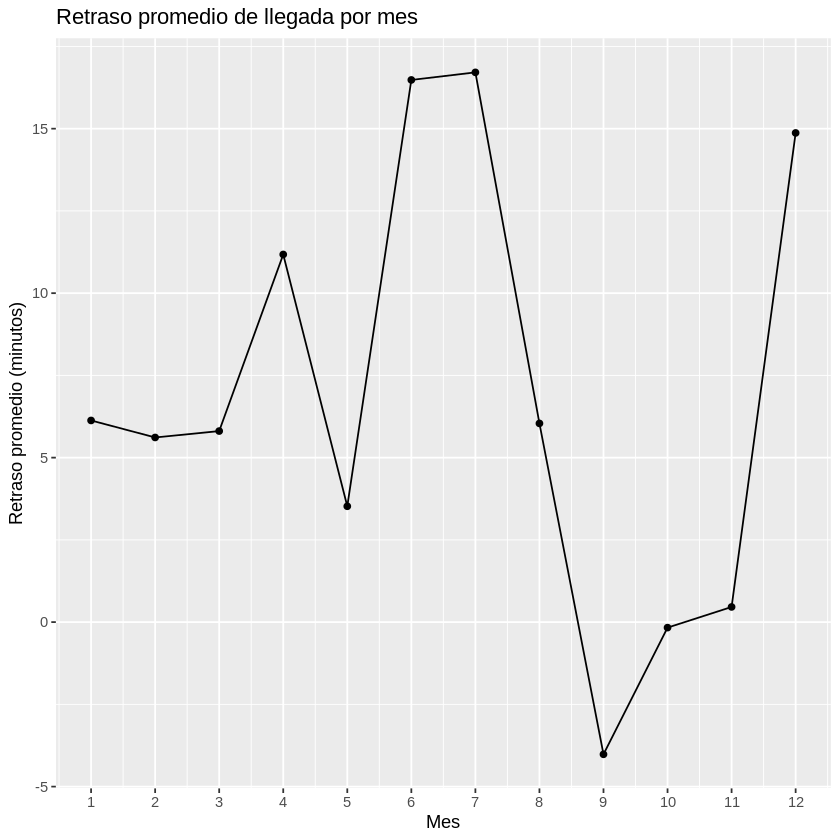

In [18]:
delay_month %>%
  ggplot(aes(x = month, y = arr_delay_prom)) +
  geom_line() +
  geom_point() +
  scale_x_continuous(breaks = 1:12) +
  labs(
    title = "Retraso promedio de llegada por mes",
    x = "Mes",
    y = "Retraso promedio (minutos)"
  )

## 11. Capas

Una fortaleza de ggplot2 es que podemos superponer capas.

`geom_smooth()` using formula = 'y ~ x'


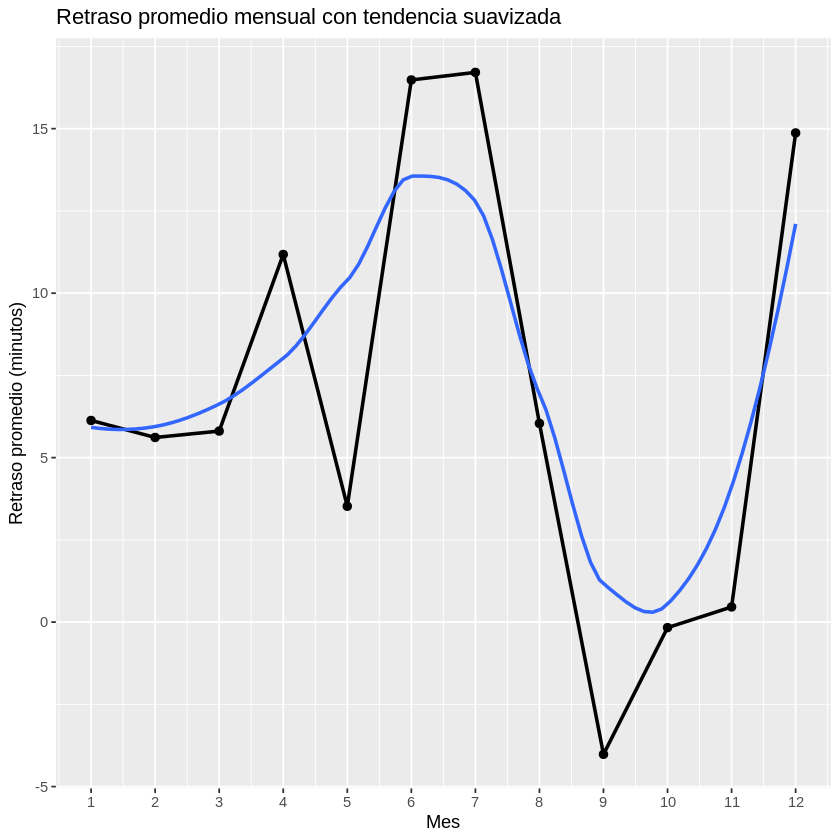

In [19]:
delay_month %>%
  ggplot(aes(x = month, y = arr_delay_prom)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  geom_smooth(se = FALSE, method = "loess", span = 0.8) +
  scale_x_continuous(breaks = 1:12) +
  labs(
    title = "Retraso promedio mensual con tendencia suavizada",
    x = "Mes",
    y = "Retraso promedio (minutos)"
  )

## 12. Transformaciones estadísticas

Algunas geometrías hacen cálculos automáticamente. Por ejemplo, el histograma cuenta casos por bin.

También podemos usar transformaciones explícitas, como `geom_smooth()`.

`geom_smooth()` using formula = 'y ~ x'


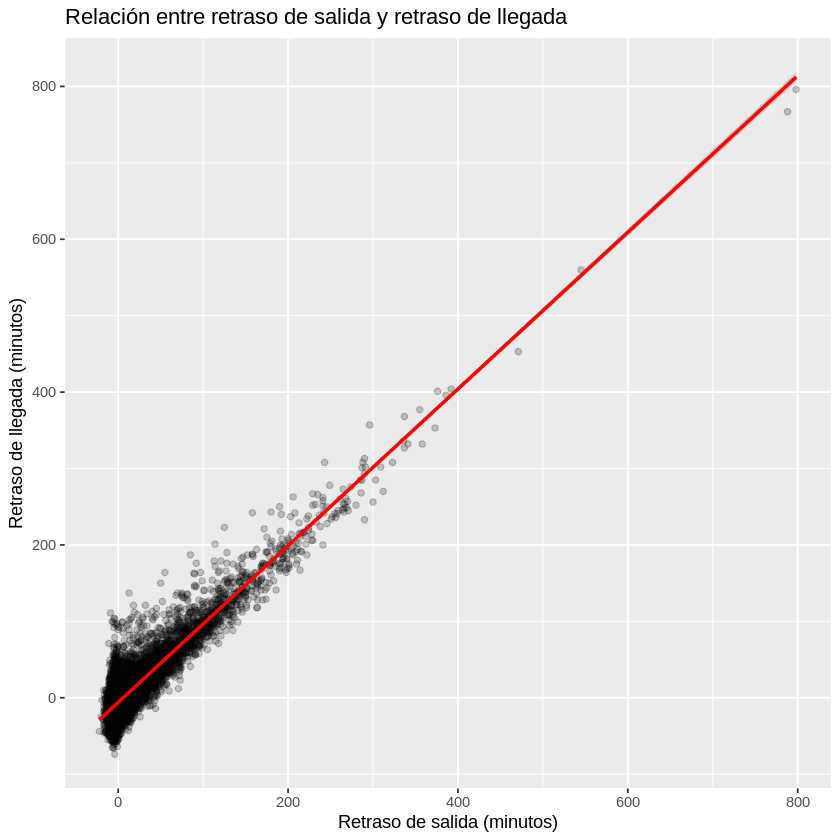

In [20]:
flights %>%
  filter(!is.na(dep_delay), !is.na(arr_delay)) %>%
  sample_n(12000) %>%
  ggplot(aes(x = dep_delay, y = arr_delay)) +
  geom_point(alpha = 0.2) +
  geom_smooth(method = "lm", color = "red", se = TRUE) +
  labs(
    title = "Relación entre retraso de salida y retraso de llegada",
    x = "Retraso de salida (minutos)",
    y = "Retraso de llegada (minutos)"
  )

## 13. Escalas

Las escalas controlan cómo se muestran los datos en los ejes, colores y leyendas.

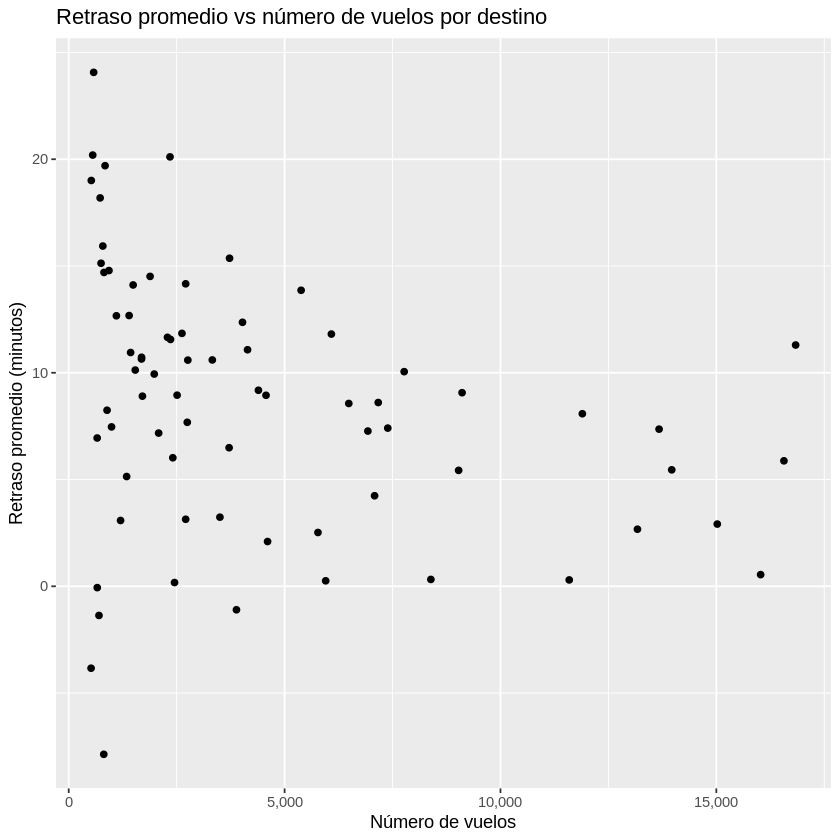

In [21]:
delay_dest <- flights %>%
  filter(!is.na(arr_delay)) %>%
  group_by(dest) %>%
  summarise(
    atraso_prom = mean(arr_delay),
    n = n()
  ) %>%
  filter(n >= 500)

delay_dest %>%
  ggplot(aes(x = n, y = atraso_prom)) +
  geom_point() +
  scale_x_continuous(labels = comma) +
  labs(
    title = "Retraso promedio vs número de vuelos por destino",
    x = "Número de vuelos",
    y = "Retraso promedio (minutos)"
  )

### Escalas de color

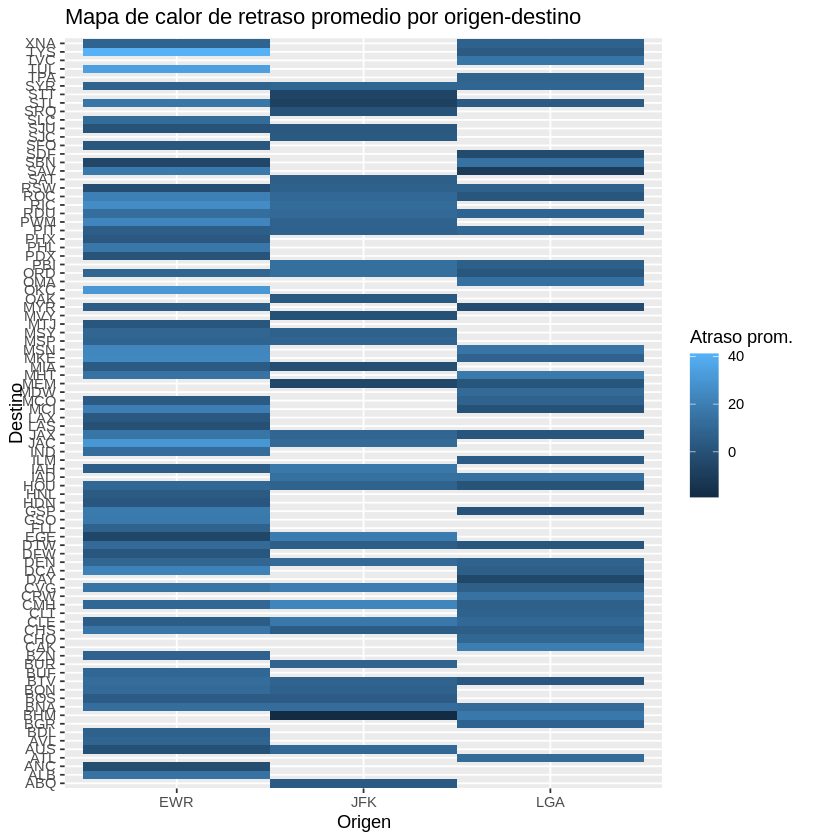

In [22]:
delay_origin_dest <- flights %>%
  filter(!is.na(arr_delay)) %>%
  group_by(origin, dest) %>%
  summarise(atraso_prom = mean(arr_delay), .groups = "drop")

delay_origin_dest %>%
  sample_n(150) %>%
  ggplot(aes(x = origin, y = dest, fill = atraso_prom)) +
  geom_tile() +
  labs(
    title = "Mapa de calor de retraso promedio por origen-destino",
    x = "Origen",
    y = "Destino",
    fill = "Atraso prom."
  )

## 14. Coordenadas

Las coordenadas cambian la forma de representar los datos.

### `coord_flip()`

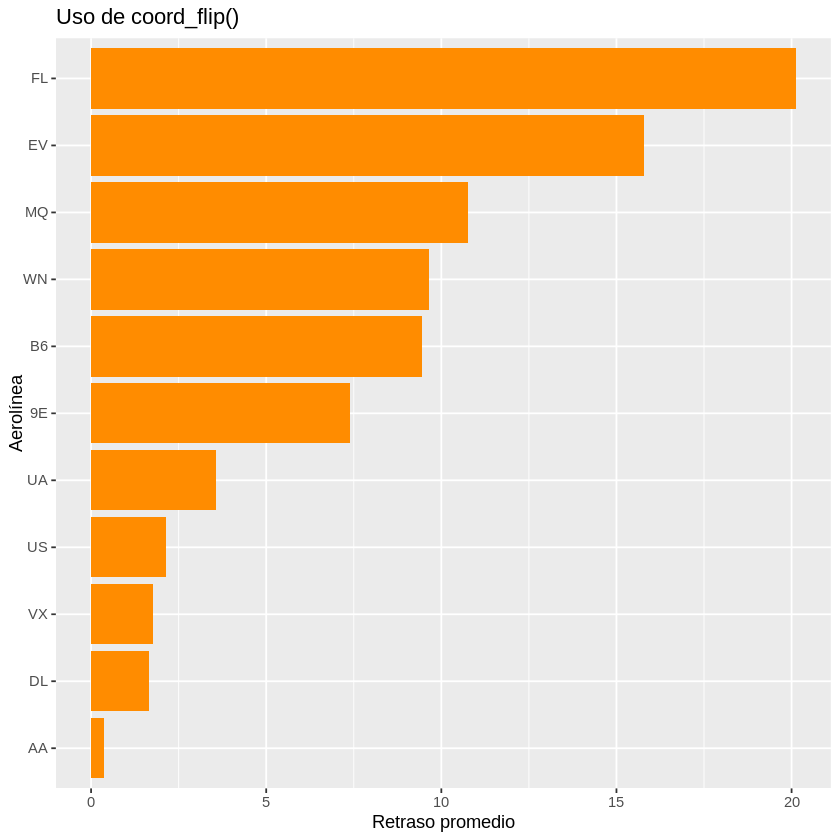

In [23]:
carrier_delay %>%
  ggplot(aes(x = reorder(carrier, atraso_prom), y = atraso_prom)) +
  geom_col(fill = "darkorange") +
  coord_flip() +
  labs(
    title = "Uso de coord_flip()",
    x = "Aerolínea",
    y = "Retraso promedio"
  )

### `coord_cartesian()` vs filtrar

`coord_cartesian()` hace zoom sin eliminar datos del cálculo estadístico.

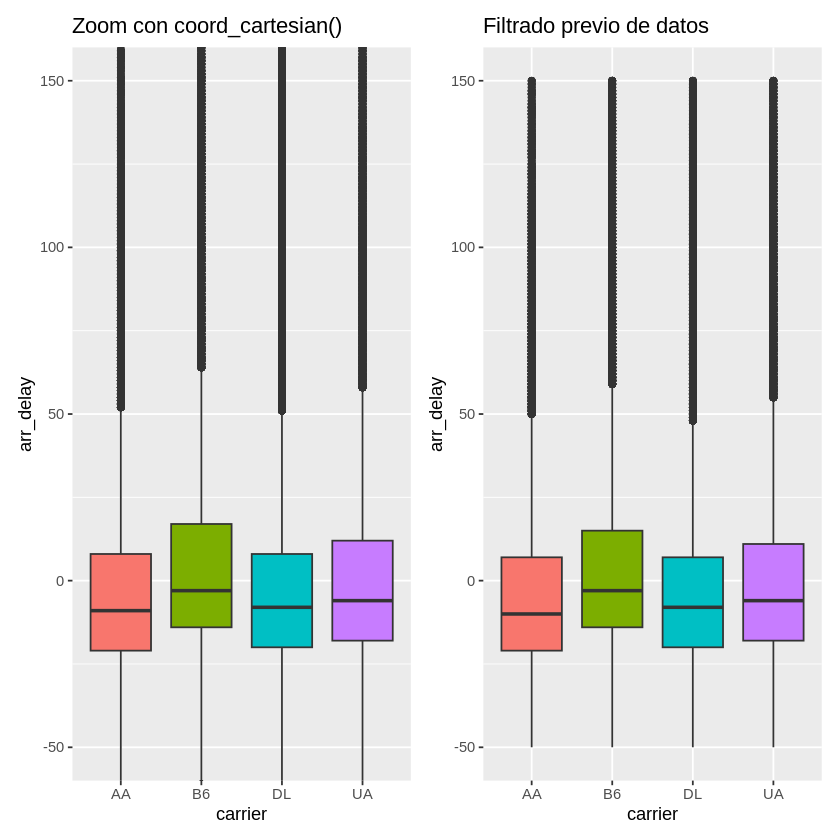

In [24]:
p1 <- flights %>%
  filter(!is.na(arr_delay), carrier %in% c("AA", "DL", "UA", "B6")) %>%
  ggplot(aes(x = carrier, y = arr_delay, fill = carrier)) +
  geom_boxplot() +
  coord_cartesian(ylim = c(-50, 150)) +
  theme(legend.position = "none") +
  labs(title = "Zoom con coord_cartesian()")

p2 <- flights %>%
  filter(!is.na(arr_delay), arr_delay >= -50, arr_delay <= 150,
         carrier %in% c("AA", "DL", "UA", "B6")) %>%
  ggplot(aes(x = carrier, y = arr_delay, fill = carrier)) +
  geom_boxplot() +
  theme(legend.position = "none") +
  labs(title = "Filtrado previo de datos")

p1 + p2

## 15. Temas y estética final

Los temas controlan el aspecto general.

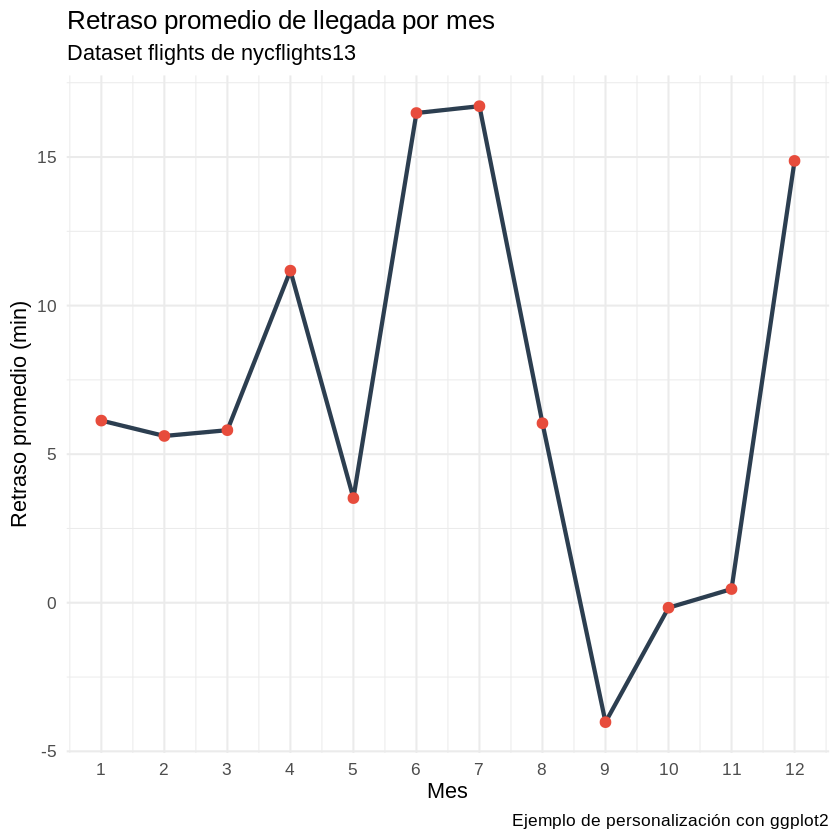

In [25]:
delay_month %>%
  ggplot(aes(x = month, y = arr_delay_prom)) +
  geom_line(linewidth = 1.2, color = "#2C3E50") +
  geom_point(size = 2.5, color = "#E74C3C") +
  scale_x_continuous(breaks = 1:12) +
  labs(
    title = "Retraso promedio de llegada por mes",
    subtitle = "Dataset flights de nycflights13",
    x = "Mes",
    y = "Retraso promedio (min)",
    caption = "Ejemplo de personalización con ggplot2"
  ) +
  theme_minimal(base_size = 13)

### Personalización más detallada

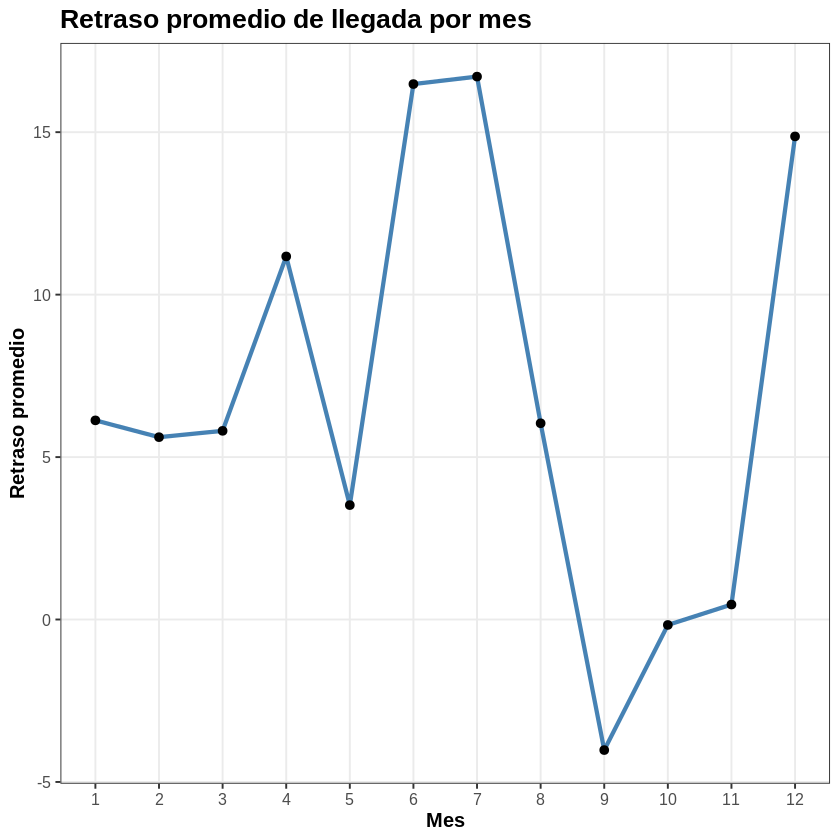

In [26]:
delay_month %>%
  ggplot(aes(x = month, y = arr_delay_prom)) +
  geom_line(linewidth = 1.2, color = "steelblue") +
  geom_point(size = 2) +
  scale_x_continuous(breaks = 1:12) +
  labs(
    title = "Retraso promedio de llegada por mes",
    x = "Mes",
    y = "Retraso promedio"
  ) +
  theme_bw(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold", size = 16),
    axis.title = element_text(face = "bold"),
    panel.grid.minor = element_blank(),
    legend.position = "bottom"
  )

## 16. Trabajar con fechas y horas

Podemos construir una fecha y luego graficar series temporales.

In [27]:
daily_delay <- flights %>%
  mutate(fecha = make_date(year, month, day)) %>%
  filter(!is.na(arr_delay)) %>%
  group_by(fecha) %>%
  summarise(arr_delay_prom = mean(arr_delay))

daily_delay

fecha,arr_delay_prom
<date>,<dbl>
2013-01-01,12.6510229
2013-01-02,12.6928879
2013-01-03,5.7333333
2013-01-04,-1.9328194
2013-01-05,-1.5258020
2013-01-06,4.2364294
2013-01-07,-4.9473118
2013-01-08,-3.2275785
2013-01-09,-0.2642777


`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


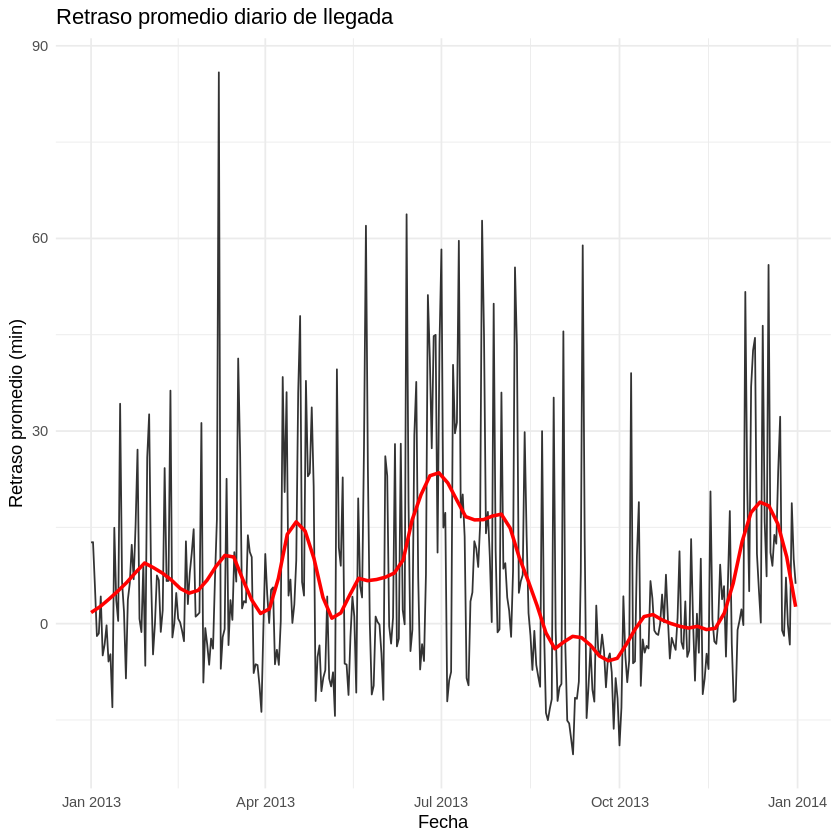

In [28]:
daily_delay %>%
  ggplot(aes(x = fecha, y = arr_delay_prom)) +
  geom_line(alpha = 0.8) +
  geom_smooth(se = FALSE, span = 0.15, color = "red") +
  labs(
    title = "Retraso promedio diario de llegada",
    x = "Fecha",
    y = "Retraso promedio (min)"
  ) +
  theme_minimal()

## 17. Anotaciones

Las anotaciones ayudan a destacar patrones.

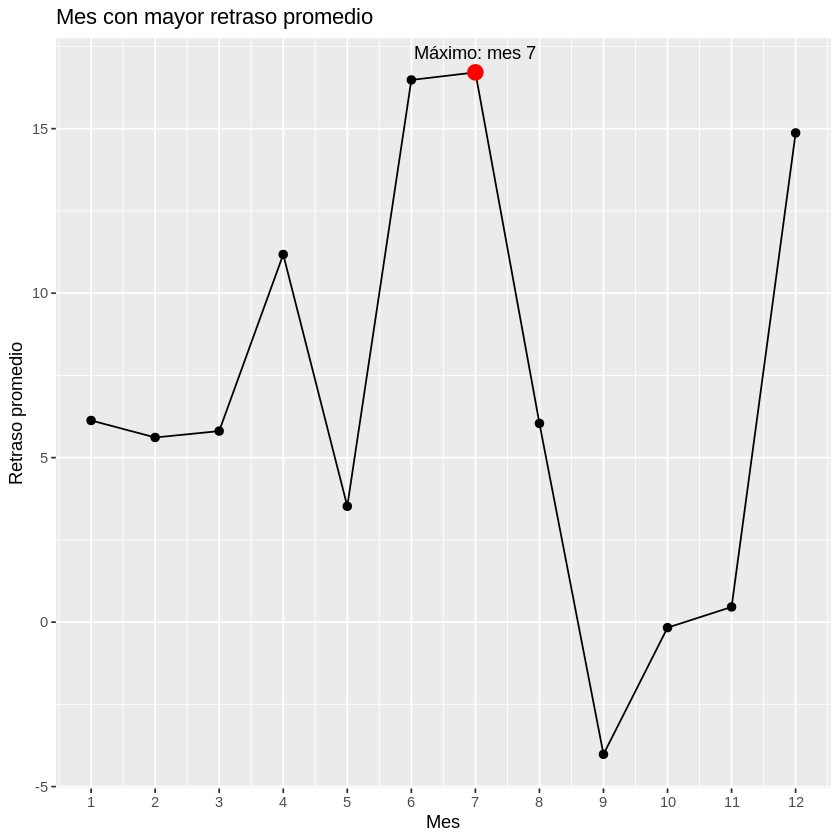

In [29]:
max_month <- delay_month %>%
  slice_max(arr_delay_prom, n = 1)

delay_month %>%
  ggplot(aes(x = month, y = arr_delay_prom)) +
  geom_line() +
  geom_point(size = 2) +
  geom_point(data = max_month, color = "red", size = 4) +
  geom_text(
    data = max_month,
    aes(label = paste0("Máximo: mes ", month)),
    vjust = -1
  ) +
  scale_x_continuous(breaks = 1:12) +
  labs(
    title = "Mes con mayor retraso promedio",
    x = "Mes",
    y = "Retraso promedio"
  )

## 18. Un ejemplo más avanzado: retraso, distancia y aerolínea

Combinemos varias ideas:
- filtrado
- resumen
- color
- tamaño
- etiquetas

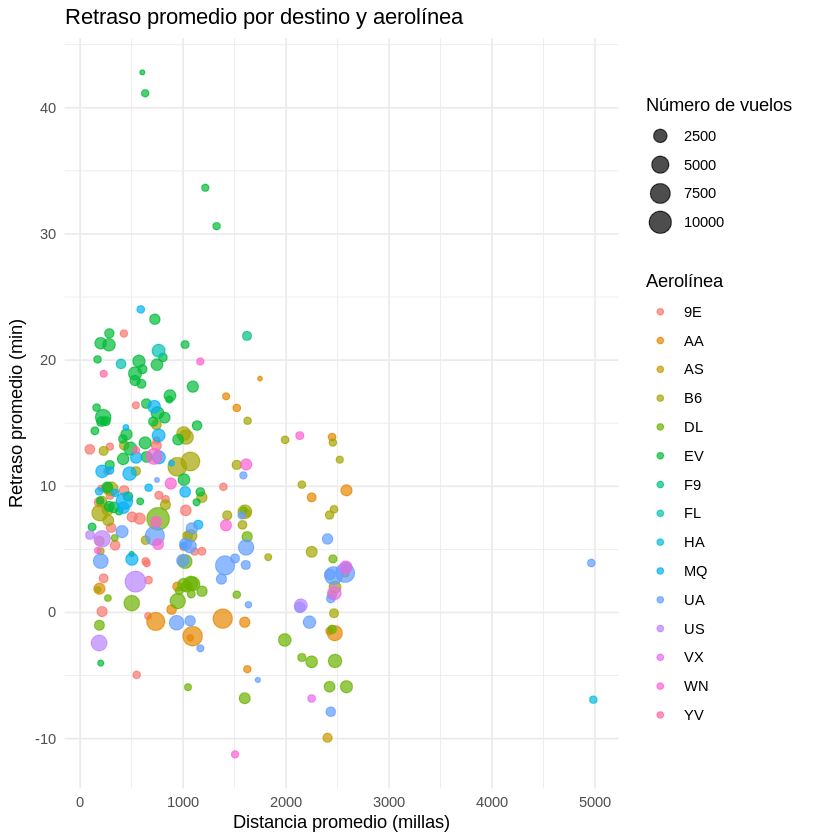

In [30]:
carrier_dest_summary <- flights %>%
  filter(!is.na(arr_delay), !is.na(distance)) %>%
  group_by(carrier, dest) %>%
  summarise(
    atraso_prom = mean(arr_delay),
    distancia_prom = mean(distance),
    n = n(),
    .groups = "drop"
  ) %>%
  filter(n >= 100)

carrier_dest_summary %>%
  ggplot(aes(x = distancia_prom, y = atraso_prom, size = n, color = carrier)) +
  geom_point(alpha = 0.7) +
  labs(
    title = "Retraso promedio por destino y aerolínea",
    x = "Distancia promedio (millas)",
    y = "Retraso promedio (min)",
    size = "Número de vuelos",
    color = "Aerolínea"
  ) +
  theme_minimal()

## 19. Buenas prácticas al usar ggplot2

1. **Empieza simple**: primero `ggplot() + geom_*()`
2. Luego agrega títulos y etiquetas
3. Usa transparencia (`alpha`) si hay muchos puntos
4. Resume datos cuando haga falta
5. Usa facetas para comparar grupos
6. No abuses de colores innecesarios
7. Revisa siempre si hay valores perdidos (`NA`)

## 20. Ejercicios propuestos

### Básicos
1. Haz un histograma de `arr_delay`.
2. Haz un gráfico de barras de `carrier`.
3. Haz un scatterplot de `air_time` vs `distance`.

### Intermedios
4. Compara `arr_delay` por `origin` con boxplots.
5. Haz un gráfico de líneas del número de vuelos por mes.
6. Usa `facet_wrap()` para comparar histogramas de `dep_delay` por origen.

### Avanzados
7. Resume el retraso promedio por destino y grafícalo.
8. Crea un heatmap con dos variables categóricas.
9. Construye una visualización propia combinando al menos:
   - una transformación previa con `dplyr`
   - un `geom_*()`
   - facetas o color
   - una mejora estética con `theme()`

## 21. Soluciones sugeridas a algunos ejercicios

In [ ]:
# 1. Histograma de arr_delay
flights %>%
  filter(!is.na(arr_delay)) %>%
  ggplot(aes(x = arr_delay)) +
  geom_histogram(binwidth = 15, fill = "skyblue", color = "white") +
  labs(title = "Histograma de arr_delay")

In [ ]:
# 2. Barras de carrier
flights %>%
  ggplot(aes(x = carrier)) +
  geom_bar(fill = "tomato") +
  labs(title = "Número de vuelos por aerolínea")

In [ ]:
# 3. Scatterplot air_time vs distance
flights %>%
  filter(!is.na(air_time), !is.na(distance)) %>%
  sample_n(8000) %>%
  ggplot(aes(x = distance, y = air_time)) +
  geom_point(alpha = 0.3) +
  labs(title = "Tiempo en el aire vs distancia")

## 22. Desafío final

Construye una visualización que responda una pregunta concreta, por ejemplo:

- ¿Qué aerolíneas tienen más retrasos?
- ¿Los vuelos largos se atrasan más?
- ¿Hay meses particularmente problemáticos?
- ¿Existen destinos consistentemente más atrasados?

Escribe primero la **pregunta**, luego prepara los datos y finalmente crea el gráfico.

## 23. Cierre

ggplot2 no es solo una librería para “hacer gráficos bonitos”.  
Es una forma **estructurada y poderosa** de pensar visualmente los datos.

La lógica general es:

**datos → mapeos estéticos → geometrías → escalas → facetas → tema**

Mientras más practiques esta secuencia, más natural te resultará construir visualizaciones claras y útiles.